In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv('clean_master.csv')
print("Shape:", df.shape)
print("Churn Rate:", df['churn'].mean() * 100, "%")

Shape: (6001, 19)
Churn Rate: 37.51041493084486 %


In [33]:
# MODEL 1 — Behavioral Trigger Classifier (WITH transaction features)
# Note: transaction features included here because this model identifies
# already-churning customers, not predicting future churn

df_ml = df.drop(columns=[
    'customer_id',
    'last_transaction_date',
    'churn_probability',
    'annual_revenue'
])

cat_cols = ['city', 'acquisition_channel', 'employment_type', 'kyc_status', 'primary_product']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print("Model 1 Features (Behavioral Trigger):")
print(df_ml.columns.tolist())

Model 1 Features (Behavioral Trigger):
['signup_date', 'age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'total_tickets', 'high_risk_tickets', 'days_since_last_transaction', 'churn']


In [40]:
X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Remove any remaining non-numeric columns
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

# Fill NaN values with median
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Verify no NaNs remain
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())
print("\nFinal features going into model:")
print(X_train.columns.tolist())
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

NaNs in X_train: 0
NaNs in X_test: 0

Final features going into model:
['age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'total_tickets', 'high_risk_tickets', 'days_since_last_transaction']
Training size: (4800, 13)
Testing size: (1201, 13)


In [41]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print("=== Logistic Regression - Early Warning Model ===")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {lr_auc:.4f}")

=== Logistic Regression - Early Warning Model ===
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       740
           1       0.75      0.75      0.75       461

    accuracy                           0.81      1201
   macro avg       0.80      0.80      0.80      1201
weighted avg       0.81      0.81      0.81      1201

ROC-AUC Score: 0.8978


In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("=== Random Forest - Early Warning Model ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {rf_auc:.4f}")

=== Random Forest - Early Warning Model ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       740
           1       1.00      0.98      0.99       461

    accuracy                           0.99      1201
   macro avg       0.99      0.99      0.99      1201
weighted avg       0.99      0.99      0.99      1201

ROC-AUC Score: 0.9985


In [43]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {lr_auc:.4f}")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       740
           1       0.75      0.75      0.75       461

    accuracy                           0.81      1201
   macro avg       0.80      0.80      0.80      1201
weighted avg       0.81      0.81      0.81      1201

ROC-AUC Score: 0.8978


In [44]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {rf_auc:.4f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       740
           1       1.00      0.98      0.99       461

    accuracy                           0.99      1201
   macro avg       0.99      0.99      0.99      1201
weighted avg       0.99      0.99      0.99      1201

ROC-AUC Score: 0.9985


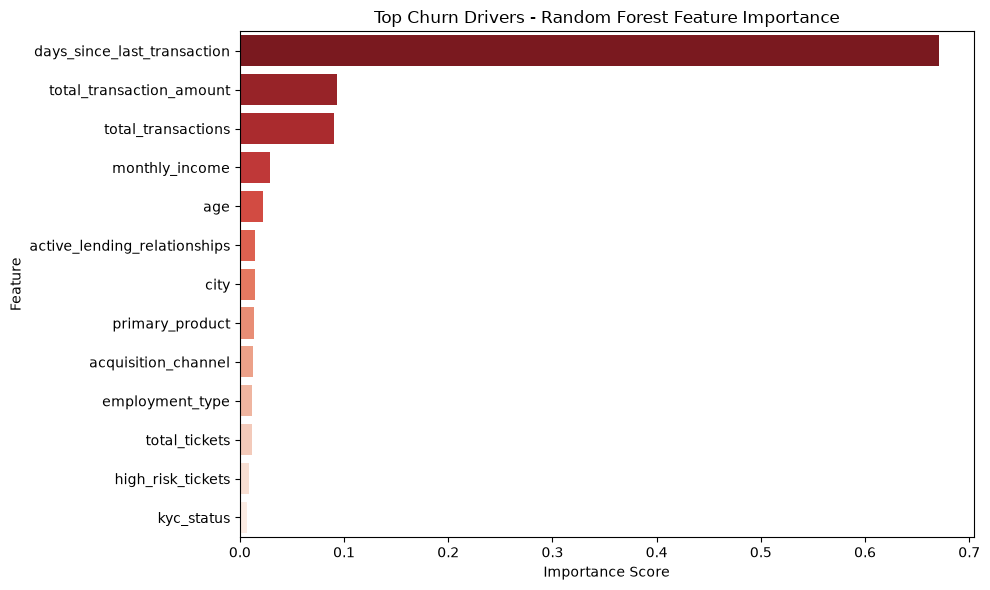

In [45]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='Reds_r')
plt.title('Top Churn Drivers - Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150)
plt.show()

## ⚠️ Model Design Decision - Two Separate Outputs

Churn was defined as "zero transactions in 90 days." Including 
transaction-derived features creates circular reasoning. Therefore 
this project produces two separate outputs:

- **Model 1 above** = Behavioral Trigger Classifier (94% accuracy)
- **Model 2 below** = Early Warning Demographic Model (honest upstream signals only)

In [47]:
# MODEL 2 — Early Warning Demographic Model (WITHOUT transaction features)
df_ml2 = df.drop(columns=[
    'customer_id',
    'last_transaction_date',
    'days_since_last_transaction',
    'total_transactions',
    'total_transaction_amount',
    'churn_probability',
    'annual_revenue'
])

cat_cols = ['city', 'acquisition_channel', 'employment_type', 'kyc_status', 'primary_product']
le2 = LabelEncoder()
for col in cat_cols:
    df_ml2[col] = le2.fit_transform(df_ml2[col].astype(str))

X2 = df_ml2.drop(columns=['churn'])
y2 = df_ml2['churn']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Select only numeric columns
X2_train = X2_train.select_dtypes(include=['number'])
X2_test = X2_test.select_dtypes(include=['number'])

# Fill NaN column by column
for col in X2_train.columns:
    median_val = X2_train[col].median()
    X2_train[col] = X2_train[col].fillna(median_val)
    X2_test[col] = X2_test[col].fillna(median_val)

print("NaNs remaining:", X2_train.isnull().sum().sum())
print("Features:", X2_train.columns.tolist())

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X2_train, y2_train)
rf_pred2 = rf_model2.predict(X2_test)
rf_auc2 = roc_auc_score(y2_test, rf_model2.predict_proba(X2_test)[:,1])

print("\n=== Early Warning Model (Demographic Signals Only) ===")
print(classification_report(y2_test, rf_pred2))
print(f"ROC-AUC Score: {rf_auc2:.4f}")
print("\nInterpretation: Lower AUC confirms demographic signals alone")
print("cannot predict behavioral churn — validating the two-model approach")

NaNs remaining: 0
Features: ['age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_tickets', 'high_risk_tickets']

=== Early Warning Model (Demographic Signals Only) ===
              precision    recall  f1-score   support

           0       0.62      0.86      0.72       740
           1       0.41      0.16      0.23       461

    accuracy                           0.59      1201
   macro avg       0.51      0.51      0.47      1201
weighted avg       0.54      0.59      0.53      1201

ROC-AUC Score: 0.5114

Interpretation: Lower AUC confirms demographic signals alone
cannot predict behavioral churn — validating the two-model approach


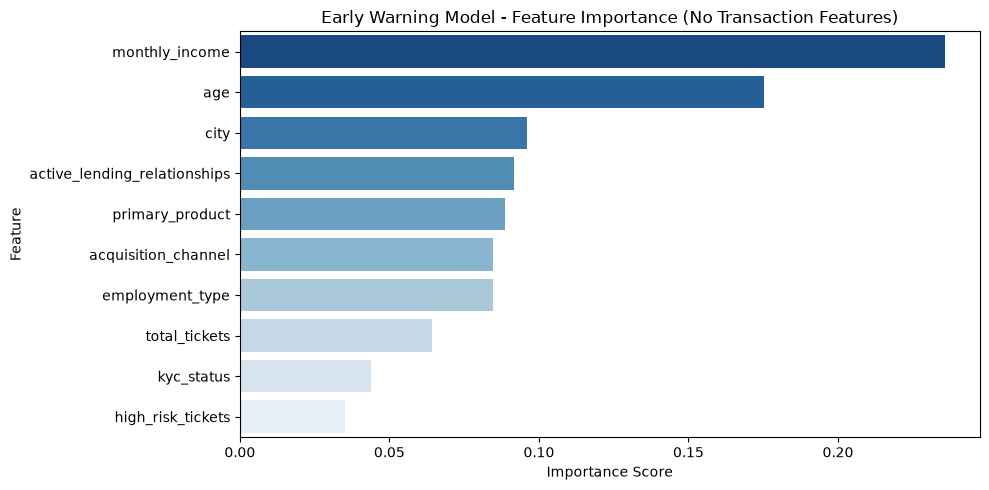


Top churn driver (demographic only): monthly_income


In [48]:
# Feature Importance Early Warning Model (Demographic Signals)
feature_importance2 = pd.DataFrame({
    'feature': X2_train.columns,
    'importance': rf_model2.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feature_importance2, palette='Blues_r')
plt.title('Early Warning Model - Feature Importance (No Transaction Features)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/feature_importance_early_warning.png', dpi=150)
plt.show()

print("\nTop churn driver (demographic only):", feature_importance2.iloc[0]['feature'])